In [1]:
from configs import *
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from scipy.linalg import solve_discrete_are
import imageio


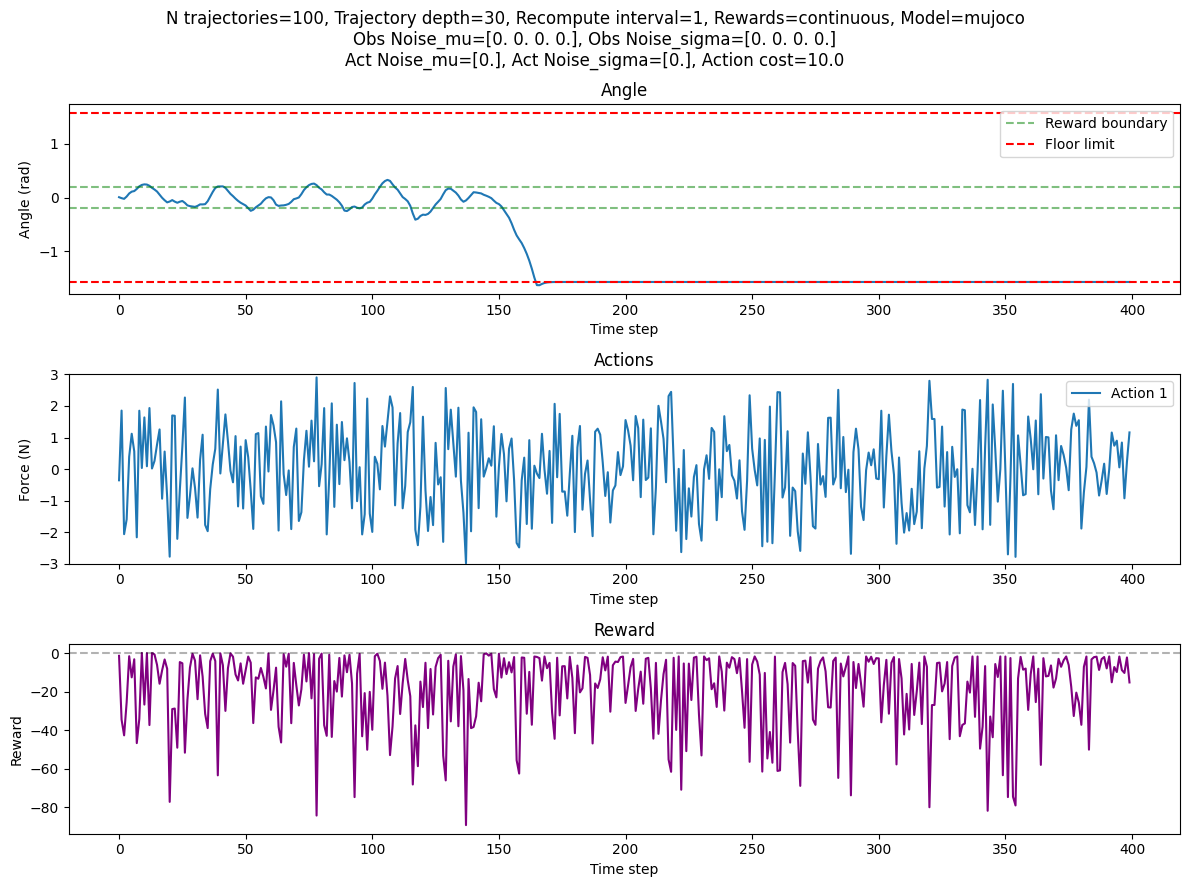

In [ ]:
def simulate(bird, n_episodes, time_steps, recompute_interval, obs_noise_mu=np.array([1.0, 0.0, 0.0, 0.0]), obs_noise_sigma=np.array([0.0, 0.0, 0.0, 0.0]), act_noise_mu=np.array([0.0]), act_noise_sigma=np.array([0.0]), reward_type='continuous', action_cost = 0.0):
    """Simulate bird."""

    simulation_data = {}
    np.random.seed(2024)

    for epi in range(n_episodes):
        episode_seed = 54 + epi
        rng = np.random.default_rng(episode_seed)  # One RNG per episode

        env = gym.make("InvertedPendulum-v5", render_mode="rgb_array", reset_noise_scale=0.01) 
        obs, _ = env.reset(seed=episode_seed)

        env.action_space.seed(episode_seed)
        env.observation_space.seed(episode_seed)

        writer = imageio.get_writer("output.gif", fps=30)

        obs_dim = env.observation_space.shape[0]
        act_dim = env.action_space.shape[0]

        observations = np.zeros((time_steps, obs_dim))
        actions = np.zeros((time_steps, act_dim))
        rewards = np.zeros(time_steps)

        # We'll initialize reward components later after the first env.step() gives us `info`
        reward_components = {}
        reward_names = None

        observations[0] = obs  # store initial observation at time 0

        for t in range(time_steps):

            if t % recompute_interval == 0: # This is the step at which we recompute the action
                        within_step = 0
                        action_trajectory = bird.mujoco_policy(env, obs)
                        action_trajectory = np.asarray(action_trajectory).flatten()
                        action = action_trajectory[within_step]
            else:
                        within_step += 1
                        action = action_trajectory[within_step]
           
            # Add action noise
            action += rng.normal(act_noise_mu, act_noise_sigma)

            # action += np.random.default_rng(episode_seed + t + 1).normal(act_noise_mu, act_noise_sigma)
            
            # Save the action before adding noise
            actions[t] = action            

            obs, reward, done, truncated, info = env.step(action)

            # If the model is discrete keep reward as is, otherwise save obs[1] as reward
            if reward_type == 'discrete':
                reward = reward - action_cost * np.sum(np.square(action[0]))  
            elif reward_type == 'continuous':
                reward = obs[1] -action_cost * np.sum(np.square(action[0]))
                # print(f"Observation at time {t}: {obs[1]}")
                # print(f"Action cost at time {t}: {np.sum(np.square(action[0]))}")
                # print(f"Reward at time {t}: {reward}")
                # print(f"Action at time {t}: {action[0]}")

            # Add observation noise
            obs += rng.normal(obs_noise_mu, obs_noise_sigma)

            # obs += np.random.default_rng(episode_seed + t + 2).normal(obs_noise_mu, obs_noise_sigma)

            # Save the true observation before adding noise
            observations[t] = obs
            rewards[t] = reward


            # Initialize reward_components dict once we see the reward names
            if t == 0 and info:
                reward_names = list(info.keys())
                reward_components = {
                    name: np.zeros(time_steps) for name in reward_names
                }

            # Record reward components if they exist
            for name in reward_components:
                reward_components[name][t] = info.get(name, 0.0)

            if epi == n_episodes - 1:
                frame = env.render()
                writer.append_data(np.asarray(frame).astype(np.uint8))

        writer.close()
        env.close()

        episode_data = {}

        for i in range(obs_dim):
            episode_data[f"state_{i+1}"] = observations[:, i]
        for i in range(act_dim):
            episode_data[f"action_{i+1}"] = actions[:, i]

        episode_data["reward"] = rewards
        for name, values in reward_components.items():
            episode_data[f"reward_{name}"] = values
        episode_data["reward_names"] = reward_names

        simulation_data[f"episode_{epi+1}"] = episode_data

    return simulation_data


# Simulate the bird
# noise_scales_list = [
#     np.array([0.0, 0.0, 0.0, 0.0]),
#     np.array([0.2, 0.2, 0.02, 0.02]),
#     np.array([0.4, 0.4, 0.04, 0.04]),
#     np.array([0.6, 0.6, 0.06, 0.06]),
# ] 
planning_width = 100 # how many trajectories to simulate
n_planning = 30 # how deep the rolout of each trajectory is
recompute_interval = 1
n_episodes = 1 
time_steps = 400
reward_type='continuous' # rewards can be 'discrete' or 'continuous'
model_type='mujoco' # model can be 'mujoco' or 'linear_full' or 'linear_reduced_<int>' where <int> is the rank of the model
obs_noise_mu=np.array([0.0, 0.0, 0.0, 0.0]) # mean of the noise added to the observations
obs_noise_sigma=np.array([0.0, 0.0, 0.0, 0.0]) # standard deviation of the noise added to the observations
act_noise_mu=np.array([0.0]) # mean of the noise added to the actions
act_noise_sigma=np.array([0.0]) # standard deviation of the noise added to the actions
action_cost = 10.0

bird = MPCShittyBird(n_actions = 10, planning_width=planning_width, n_planning=n_planning, reward_type=reward_type, model_type=model_type, action_cost=action_cost)

# Simulate the bird
simulation_data = simulate(bird, n_episodes=n_episodes, time_steps=time_steps,recompute_interval=recompute_interval, obs_noise_mu=obs_noise_mu, obs_noise_sigma=obs_noise_sigma, act_noise_mu=act_noise_mu, act_noise_sigma=act_noise_sigma, reward_type=reward_type, action_cost=action_cost)

episode1 = simulation_data["episode_1"]

angle = episode1["state_2"]

reward = episode1["reward"]

# Gather all action dimensions into a 2D array (time_steps, act_dim)
action_keys = sorted([k for k in episode1 if k.startswith("action_")])  # sorted for order
actions = np.vstack([episode1[k] for k in action_keys]).T

plt.figure(figsize=(12, 9))  # Made figure taller to accommodate third subplot
plt.suptitle(
    f'N trajectories={planning_width}, Trajectory depth={n_planning}, Recompute interval={recompute_interval}, Rewards={reward_type}, Model={model_type}\n'
    f'Obs Noise_mu={obs_noise_mu}, Obs Noise_sigma={obs_noise_sigma}\n'
    f'Act Noise_mu={act_noise_mu}, Act Noise_sigma={act_noise_sigma}, Action cost={action_cost}',
    fontsize=12
)

# Plot the angle
plt.subplot(3, 1, 1)  # Changed to 3 rows
plt.plot(angle)
plt.title('Angle')
plt.xlabel('Time step')
plt.ylabel('Angle (rad)')
plt.axhline(y=-0.2, color='g', linestyle='--', alpha=0.5, label='Reward boundary')
plt.axhline(y=0.2, color='g', linestyle='--', alpha=0.5)
plt.axhline(y=-1.573, color='r', linestyle='--', label='Floor limit')
plt.axhline(y=1.573, color='r', linestyle='--')
plt.legend()

# Plot the actions
plt.subplot(3, 1, 2)  # Changed to 3 rows
plt.plot(actions)
plt.title('Actions')
plt.xlabel('Time step')
plt.ylabel('Force (N)')
plt.ylim(-3, 3)
plt.legend([f'Action {i+1}' for i in range(actions.shape[1])], loc='upper right')

# Add reward subplot
plt.subplot(3, 1, 3)
plt.plot(reward, 'purple')
plt.title('Reward')
plt.xlabel('Time step')
plt.ylabel('Reward')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()



Running simulation with recompute_interval=1, n_planning=10
Running simulation with recompute_interval=1, n_planning=40
Running simulation with recompute_interval=1, n_planning=60


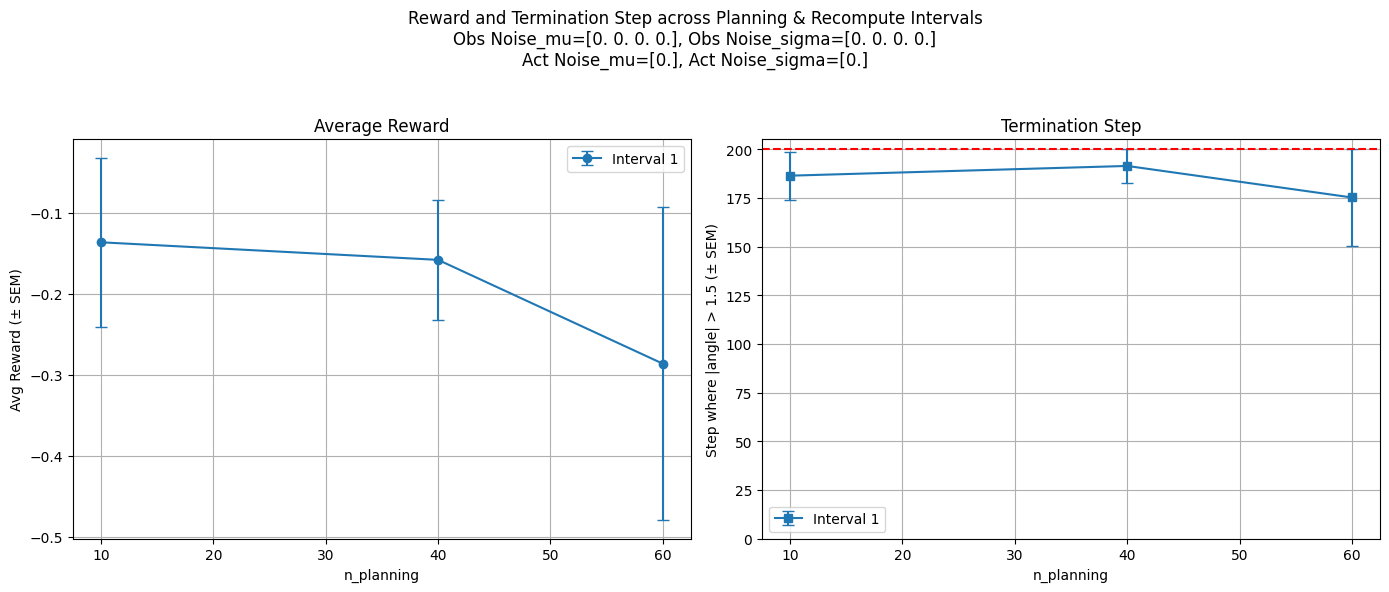

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# --- Config ---
planning_width = 200
reward_type = 'continuous'
model_type = 'mujoco'

obs_noise_mu = np.array([0.0, 0.0, 0.0, 0.0])
obs_noise_sigma = np.array([0.0, 0.0, 0.0, 0.0])
act_noise_mu = np.array([0.0])
act_noise_sigma = np.array([0.0])

recompute_intervals = [1]
# n_planning_values = [3,4,5,6,7,8,9,10]
n_planning_values = [10, 40, 60]

n_episodes = 5
time_steps = 200

# --- Run Simulations ---

# Initialize both results and termination_results in the same structure
results = {
    interval: {n: [] for n in n_planning_values if n >= interval}
    for interval in recompute_intervals
}

termination_results = {
    interval: {n: [] for n in n_planning_values if n >= interval}
    for interval in recompute_intervals
}

for interval in recompute_intervals:
    for n_planning in n_planning_values:

        print(f"Running simulation with recompute_interval={interval}, n_planning={n_planning}")

        if n_planning < interval:
            break  # skip invalid configuration

        bird = MPCShittyBird(
            n_actions=10,
            planning_width=planning_width,
            n_planning=n_planning,
            reward_type=reward_type,
            model_type=model_type
        )

        simulation_data = simulate(
            bird,
            n_episodes=n_episodes,
            time_steps=time_steps,
            recompute_interval=interval,
            obs_noise_mu=obs_noise_mu,
            obs_noise_sigma=obs_noise_sigma,
            act_noise_mu=act_noise_mu,
            act_noise_sigma=act_noise_sigma
        )

        for episode_data in simulation_data.values():
            angle = episode_data["state_2"]

            # --- Compute reward ---
            reward = -np.mean(np.abs(angle))
            results[interval][n_planning].append(reward)

            # --- Compute termination step ---
            exceed_indices = np.where(np.abs(angle) > 1.5)[0]
            if len(exceed_indices) > 0:
                termination_step = int(exceed_indices[0])
            else:
                termination_step = len(angle)

            termination_results[interval][n_planning].append(termination_step)

# --- Initialize Storage ---
results_with_stats = {}
termination_with_stats = {}

# --- Compute Stats ---
for interval, planning_data in results.items():
    n_list = []
    reward_mean_list = []
    reward_sem_list = []

    termination_mean_list = []
    termination_sem_list = []

    for n_planning, reward_list in planning_data.items():
        term_list = termination_results[interval][n_planning]  # ← FIXED here

        if len(reward_list) > 0:
            n_list.append(n_planning)
            reward_mean_list.append(np.mean(reward_list))
            reward_sem_list.append(stats.sem(reward_list))

            if len(term_list) == len(reward_list):  # Just to be safe
                termination_mean_list.append(np.mean(term_list))
                termination_sem_list.append(stats.sem(term_list))
            else:
                termination_mean_list.append(np.nan)
                termination_sem_list.append(np.nan)

    results_with_stats[interval] = {
        "n_planning": n_list,
        "means": reward_mean_list,
        "std_errors": reward_sem_list
    }

    termination_with_stats[interval] = {
        "n_planning": n_list,
        "means": termination_mean_list,
        "std_errors": termination_sem_list
    }

# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Plot 1: Average Reward
for interval, stats_dict in results_with_stats.items():
    x = np.array(stats_dict["n_planning"])
    y = np.array(stats_dict["means"])
    yerr = np.array(stats_dict["std_errors"])
    jitter = (interval - np.mean(recompute_intervals)) * 0.05
    x_jittered = x + jitter
    axs[0].errorbar(x_jittered, y, yerr=yerr, marker='o', capsize=4, label=f'Interval {interval}')

axs[0].set_title('Average Reward')
axs[0].set_xlabel('n_planning')
axs[0].set_ylabel('Avg Reward (± SEM)')
axs[0].grid(True)
axs[0].legend()

# Plot 2: Termination Step
for interval, stats_dict in termination_with_stats.items():
    x = np.array(stats_dict["n_planning"])
    y = np.array(stats_dict["means"])
    yerr = np.array(stats_dict["std_errors"])
    jitter = (interval - np.mean(recompute_intervals)) * 0.05
    x_jittered = x + jitter
    axs[1].errorbar(x_jittered, y, yerr=yerr, marker='s', capsize=4, label=f'Interval {interval}')

axs[1].set_title('Termination Step')
axs[1].set_xlabel('n_planning')
axs[1].set_ylabel('Step where |angle| > 1.5 (± SEM)')
axs[1].set_ylim(0, time_steps + 5)
axs[1].grid(True)
axs[1].legend()
axs[1].axhline(y=time_steps, color='r', linestyle='--', label='Max Time Steps')


plt.suptitle(
    f'Reward and Termination Step across Planning & Recompute Intervals\n'
    f'Obs Noise_mu={obs_noise_mu}, Obs Noise_sigma={obs_noise_sigma}\n'
    f'Act Noise_mu={act_noise_mu}, Act Noise_sigma={act_noise_sigma}',
    fontsize=12
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

plt.show()
